In [24]:
import tensorflow as tf
from tensorflow import keras
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras.models import Sequential
from keras.losses import BinaryCrossentropy
from keras.optimizers import AdamW
from keras.layers import Dense, Input, Dropout, Flatten

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
conv_model = VGG16(include_top=False, 
              weights="imagenet",
              input_shape=(150, 150, 3) # since we don't have fully connected layers, we can have every sizes of input image.
              ) # output shape is : 4*4*512

conv_model.summary()

In [ ]:
train_data_dir = "/mnt/d/piicture/dataset_cat_dog/train"
val_data_dir = "/mnt/d/piicture/dataset_cat_dog/val"
test_data_dir = "/mnt/d/piicture/dataset_cat_dog/test"

train_loader = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                           image_size=(150, 150),
                                                           batch_size=16,
                                                           label_mode="binary",
                                                           shuffle=True)

val_loader = tf.keras.utils.image_dataset_from_directory(val_data_dir,
                                                         image_size=(150, 150),
                                                         batch_size=16,
                                                         label_mode="binary",
                                                         shuffle=False)

test_loader = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                          image_size=(150, 150),
                                                          batch_size=16,
                                                          label_mode="binary",
                                                          shuffle=True)

Found 2 files belonging to 2 classes.
Found 2 files belonging to 2 classes.


W0000 00:00:1776786471.316895    1980 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Text(0.5, 1.0, '[1.]')

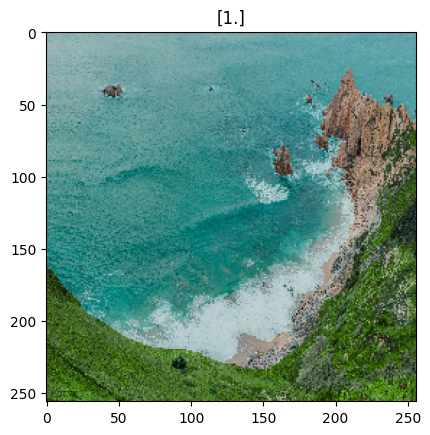

In [10]:
for images, labels in train_loader:
    image_1 = images[0]
    label_0 = labels[0]

    break

plt.imshow(image_1.numpy().astype(np.uint8)); plt.title(label_0.numpy())

In [11]:
train_loader.class_names

['cat', 'dog']

In [12]:
def extract_feature(data_generator, batch_size, num_samples, model):
    import numpy as np

    features = np.zeros(shape=(num_samples, 4, 4, 512))
    labels = np.zeros(shape=(num_samples, 1))

    i = 0
    for images, batch_labels in data_generator:
        features_batch = model.predict(images, verbose=0)

        start = i * batch_size
        end = start + images.shape[0]

        features[start:end] = features_batch
        labels[start:end] = batch_labels

        i += 1
        if end >= num_samples:
            break

    return features, labels


In [ ]:
train_features, train_labels = extract_feature(train_loader, 20, 1000, conv_model)
val_features, val_labels = extract_feature(val_loader, 20, 500, conv_model)
test_features, test_labels = extract_feature(test_loader, 20, 200, conv_model)

In [ ]:
train_features_flattened = np.reshape(train_features, newshape=(train_features.shape[0], -1))
val_features_flattened = np.reshape(val_features, newshape=(val_features.shape[0], -1))
test_features_flattened = np.reshape(test_features, newshape=(test_features.shape[0], -1))

In [18]:
calc_model = Sequential()

calc_model.add(Input(shape=(4 * 4 * 512, )))
calc_model.add(Dense(256, activation='relu'))
calc_model.add(Dropout(0.5))
calc_model.add(Dense(1, activation='sigmoid'))


In [19]:
calc_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,665 (8.00 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
calc_model.compile(optimizer=AdamW(learning_rate=2e-5),
                   loss=BinaryCrossentropy,
                   metrics=['accuracy'])

In [ ]:
history = calc_model.fit(train_features_flattened, train_labels,
                        batch_size=20, 
                        epochs=100,
                        validation_data=(val_features_flattened, val_labels))

NameError: name 'train_features_flattened' is not defined

____

## TransferLearning

In [ ]:
conv_model.trainable = False

model = Sequential()

model.add(conv_model)
model.add(Flatten)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

NameError: name 'conv_model' is not defined

In [ ]:
model.trainable_weights // 2

In [ ]:
calc_model.compile(optimizer=AdamW(learning_rate=2e-5),
                   loss=BinaryCrossentropy,
                   metrics=['accuracy'])

In [ ]:
history = calc_model.fit(train_loader,
                        batch_size=20, 
                        epochs=100,
                        validation_data=val_loader)

___

## FineTuning

In [ ]:
seen_layer = False
conv_model.trainable = False

for layer in conv_model.layers:
    print(f"{layer.name} --> {layer.trainable}")

    if layer.name == "bloc5_conv1":
        seen_layer = True
    if seen_layer:
        layer.trainable = True
        print(f"{layer.name} --> set trainable1")


In [ ]:
calc_model.compile(optimizer=AdamW(learning_rate=1e-6),
                   loss=BinaryCrossentropy,
                   metrics=['accuracy'])

In [ ]:
history = calc_model.fit(train_loader,
                        batch_size=20, 
                        epochs=50,
                        validation_data=val_loader)